In [87]:
## Import Libraries
import re
import math
import json
import random
from collections import Counter
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


# Paste the Wikipedia link you want to use here. 
# The article should be reasonably long (at least a few thousand words) for good results.
WIKI_URL = "https://en.wikipedia.org/wiki/Wikipedia"
RANDOM_SEED = 42


In [76]:
## Ensure NLTK resources
def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)

In [77]:
## Festch Wikipedia Article
def fetch_wikipedia_article(url: str) -> str:
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; SGNS-Wikipedia-Training/1.0)"
    }
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    # Extract main content text from the Wikipedia page
    soup = BeautifulSoup(resp.text, "html.parser")

    content_div = soup.find("div", {"id": "mw-content-text"})
    if content_div is None:
        raise ValueError("Could not find Wikipedia article content.")

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = []

    for p in paragraphs:
        txt = p.get_text(" ", strip=True)
        if txt:
            text_blocks.append(txt)

    text = "\n".join(text_blocks)

    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [78]:
## Preprocessing
def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)

    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue

        tokens = word_tokenize(sent)

        cleaned = []
        for tok in tokens:
            tok = tok.strip("-")
            if not tok:
                continue
            if tok.isdigit():
                continue
            if len(tok) < 2:
                continue
            cleaned.append(tok)

        if len(cleaned) >= 3:
            processed.append(cleaned)

    return processed

In [79]:
## Corpus Statistics
def corpus_stats(sentences: List[List[str]]) -> Dict[str, int]:
    flat = [w for s in sentences for w in s]
    vocab = set(flat)
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(vocab),
    }

In [80]:
## Train SGNS Model
def train_sgns(sentences: List[List[str]], vector_size = 100, window = 5) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=1,
        workers=4,
        sg=1,          # 0 = CBOW, 1 = skip-gram
        negative=10,   # negative sampling
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )
    return model

In [81]:
## Evaluate Cosine Relatedness
def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index

def cosine(model: Word2Vec, w1: str, w2: str) -> float:
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])

def evaluate_relatedness(model: Word2Vec, test_pairs: List[Tuple[str, str, float]]):
    gold = []
    pred = []
    covered = []

    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine(model, w1, w2)
            gold.append(score)
            pred.append(sim)
            covered.append((w1, w2, score, sim))

    return {
        "covered_items": covered,
        "coverage": len(covered),
        "total": len(test_pairs),
    }

In [82]:
## Evaluate Analogies
def evaluate_analogies(model: Word2Vec, analogies: List[Tuple[str, str, str, str]]):
    """
    Analogy format: a:b :: c:d
    Checks whether most_similar(positive=[b,c], negative=[a]) returns d.
    """
    covered = 0
    correct = 0
    details = []

    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            try:
                preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
                predicted_words = [w for w, _ in preds]
                hit = d in predicted_words
                correct += int(hit)
                details.append({
                    "analogy": f"{a}:{b}::{c}:?",
                    "expected": d,
                    "predictions": predicted_words,
                    "correct_in_top5": hit
                })
            except KeyError:
                pass

    accuracy = correct / covered if covered else float("nan")
    return {
        "coverage": covered,
        "total": len(analogies),
        "accuracy_top5": accuracy,
        "details": details
    }

In [83]:
## Print Nearest Neighbors
def print_top_neighbors(model: Word2Vec, words: List[str], topn: int = 8):
    print("\n=== Nearest Neighbors ===")
    for word in words:
        if has_word(model, word):
            neighbors = model.wv.most_similar(word, topn=topn)
            print(f"\n{word}:")
            for neigh, score in neighbors:
                print(f"  {neigh:20s} {score:.4f}")
        else:
            print(f"\n{word}: [OOV]")

#### Main

In [84]:
## Main Execution
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Downloading Wikipedia article...")
raw_text = fetch_wikipedia_article(WIKI_URL)

print("Preprocessing text...")
sentences = preprocess_text(raw_text)
stats = corpus_stats(sentences)

print("\n=== Corpus Stats ===")
for k, v in stats.items():
    print(f"{k}: {v}")

print("\nTraining Skip-gram with Negative Sampling...")
model = train_sgns(sentences)

print("\nVocabulary size learned:", len(model.wv))

## Neighbor Test
probe_words = [
    "wikipedia", "encyclopedia", "wikimedia", "online", "articles",
    "foundation", "article", "free", "knowledge", "wales"
]
print_top_neighbors(model, probe_words, topn=8)

## Relatedness Test
relatedness_test = [
    # These scores in the pairs are just examples, you are the ones providing it. 
    # You can adjust them based on your understanding of the article and what you expect the model to learn.
    ("wikimedia", "foundation", 0.75),
    ("online", "encyclopedia", 0.70),
    ("english", "wikipedia", 0.45),
    ("reference", "work", 0.45),
    ("free", "online", 0.55),

    ("systematic","bias",0.25),
    ("misinformation", "source", 0.10),
    ("censor", "information", 0.05),
]

rel_results = evaluate_relatedness(model, relatedness_test)

print("\n=== Relatedness Test Set ===")
print(f"Coverage: {rel_results['coverage']}/{rel_results['total']}")
for w1, w2, gold, pred in rel_results["covered_items"]:
    print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")

## Analogy Test
analogy_test = [
    ("source", "information", "articles", "reference"),
    ("foundation", "organization", "collaboration", "community"),
    ("traffic", "visit", "used", "cited"),
]

analogy_results = evaluate_analogies(model, analogy_test)

print("\n=== Analogy Test Set ===")
print(f"Coverage: {analogy_results['coverage']}/{analogy_results['total']}")
print(f"Top-5 accuracy: {analogy_results['accuracy_top5']}")
for item in analogy_results["details"]:
    print(json.dumps(item, ensure_ascii=False))

# Direct Similarity Checks
print("\n=== Direct Similarity Checks ===")
# Change these pairs based on what you expect to be related/unrelated in the article and what words are in the model.
check_pairs = [
    ("wikimedia", "foundation"),
    ("online", "encyclopedia"),
    ("english", "wikipedia"),
    ("reference", "work"),
    ("censor","information"),
]
for w1, w2 in check_pairs:
    if has_word(model, w1) and has_word(model, w2):
        print(f"{w1:10s} <-> {w2:10s}: {cosine(model, w1, w2):.4f}")
    else:
        print(f"{w1:10s} <-> {w2:10s}: OOV")

# Save model
model.save("exercise_5_skipgram_sgns.model")
print("\nSaved model to: exercise_5_skipgram_sgns.model")

print("\nDone.")

Preprocessing text...

=== Corpus Stats ===
num_sentences: 2014
num_tokens: 23163
vocab_size: 5103

Training Skip-gram with Negative Sampling...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



Vocabulary size learned: 5103

=== Nearest Neighbors ===

wikipedia:
  would                0.3507
  registered           0.3430
  alternative          0.3398
  translate            0.3350
  produced             0.3337
  critic               0.3311
  improving            0.3309
  outspoken            0.3253

encyclopedia:
  scholarpedia         0.6204
  blunders             0.6109
  apart                0.5931
  torn                 0.5820
  assembled            0.5643
  yongle               0.5623
  goal                 0.5496
  distribute           0.5485

wikimedia:
  foundation           0.6346
  selects              0.5690
  gericht              0.5610
  welcomes             0.5575
  cyrusone             0.5568
  projects             0.5564
  trustees             0.5524
  nsa                  0.5512

online:
  torn                 0.5657
  apart                0.5612
  safety               0.5453
  legislation          0.5251
  teach                0.5213
  petition             0

### Retrain Model with New Config

In [86]:
print("\nRetraining with window=10...")
model_new = train_sgns(sentences, window=10)

print("\nVocabulary size learned (new):", len(model_new.wv))

# Compare relatedness
rel_results_new = evaluate_relatedness(model_new, relatedness_test)
print("\n=== Relatedness Comparison ===")
print("Original (window=5):")
print(f"Coverage: {rel_results['coverage']}/{rel_results['total']}")
for w1, w2, gold, pred in rel_results["covered_items"][:5]:  # Show first 5
    print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")

print("\nNew (window=10):")
print(f"Coverage: {rel_results_new['coverage']}/{rel_results_new['total']}")
for w1, w2, gold, pred in rel_results_new["covered_items"][:5]:
    print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")

analogy_results_new = evaluate_analogies(model_new, analogy_test)
print("\n=== Analogy Test Set ===")

print("Original (window=5):")
print(f"Coverage: {analogy_results['coverage']}/{analogy_results['total']}")
print(f"Top-5 accuracy: {analogy_results['accuracy_top5']}")
for item in analogy_results["details"]:
    print(json.dumps(item, ensure_ascii=False))

print("\nNew (window=10):")
print(f"Coverage: {analogy_results_new['coverage']}/{analogy_results_new['total']}")
print(f"Top-5 accuracy: {analogy_results_new['accuracy_top5']}")
for item in analogy_results_new["details"]:
    print(json.dumps(item, ensure_ascii=False))

print("\n=== Direct Similarity Checks ===")

print("Original (window=5):")
for w1, w2 in check_pairs:
    if has_word(model, w1) and has_word(model, w2):
        print(f"{w1:10s} <-> {w2:10s}: {cosine(model, w1, w2):.4f}")
    else:
        print(f"{w1:10s} <-> {w2:10s}: OOV")

print("\nNew (window=10):")     
for w1, w2 in check_pairs:
    if has_word(model_new, w1) and has_word(model_new, w2):
        print(f"{w1:10s} <-> {w2:10s}: {cosine(model_new, w1, w2):.4f}")
    else:
        print(f"{w1:10s} <-> {w2:10s}: OOV")

# Save model
model.save("exercise_5_skipgram_sgns.model")
print("\nSaved model to: exercise_5_skipgram_sgns.model")


Retraining with window=10...

Vocabulary size learned (new): 5103

=== Relatedness Comparison ===
Original (window=5):
Coverage: 8/8
wikimedia  - foundation | gold=0.75 pred=0.6346
online     - encyclopedia | gold=0.70 pred=0.3611
english    - wikipedia  | gold=0.45 pred=0.2657
reference  - work       | gold=0.45 pred=0.3587
free       - online     | gold=0.55 pred=0.2717

New (window=10):
Coverage: 8/8
wikimedia  - foundation | gold=0.75 pred=0.6914
online     - encyclopedia | gold=0.70 pred=0.4071
english    - wikipedia  | gold=0.45 pred=0.2628
reference  - work       | gold=0.45 pred=0.3705
free       - online     | gold=0.55 pred=0.2803

=== Analogy Test Set ===
Original (window=5):
Coverage: 3/3
Top-5 accuracy: 0.0
{"analogy": "source:information::articles:?", "expected": "reference", "predictions": ["tied", "comprise", "relevant", "living", "biographical"], "correct_in_top5": false}
{"analogy": "foundation:organization::collaboration:?", "expected": "community", "predictions": [

### PCA Visualization


Visualizing word embeddings with PCA...
PCA visualization saved to: word_embeddings_pca.png

Done.


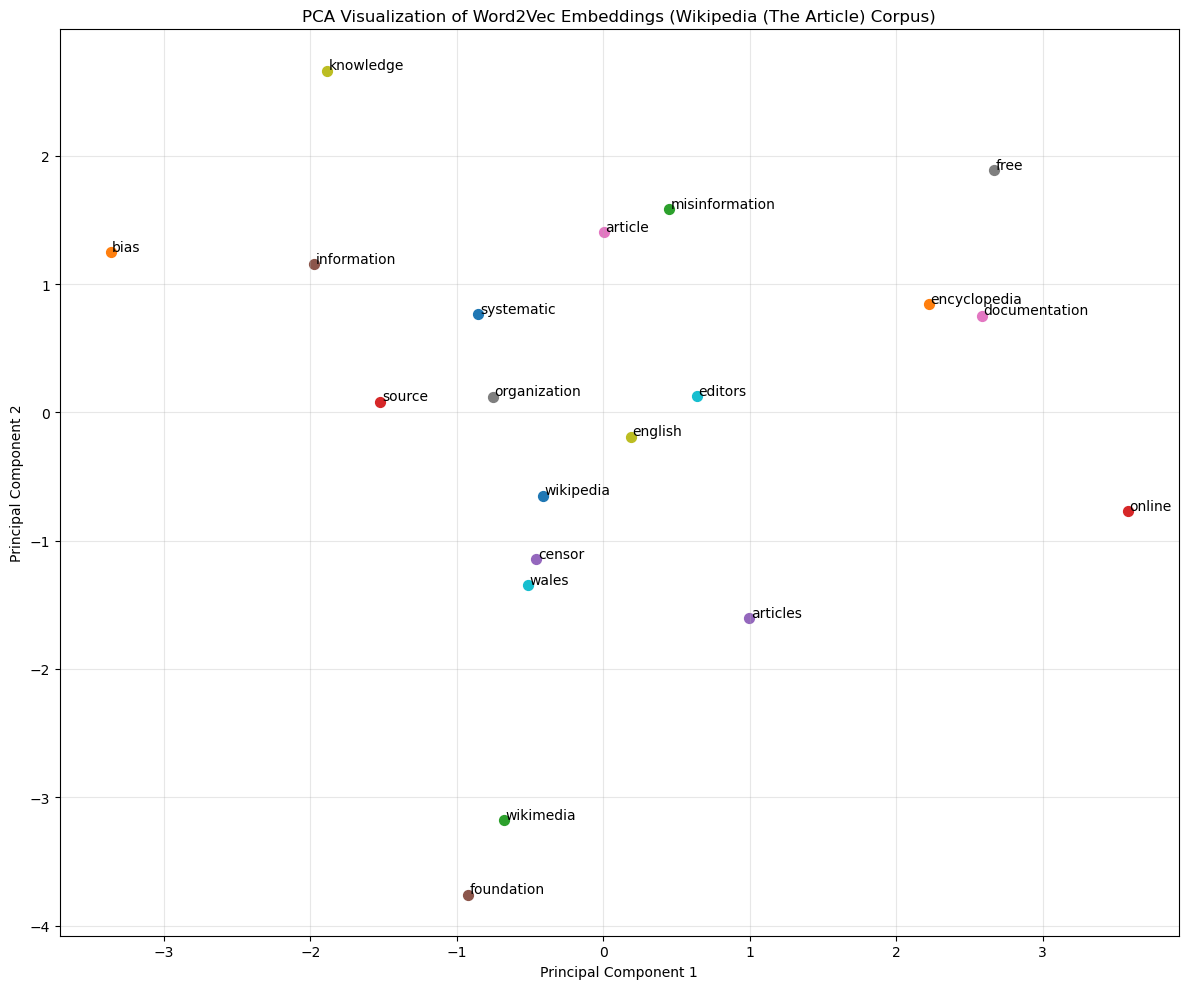

In [91]:
# Visualize vectors using PCA
print("\nVisualizing word embeddings with PCA...")
words_to_visualize = [
    "wikipedia", "encyclopedia", "wikimedia", "online", "articles",
    "foundation", "article", "free", "knowledge", "wales",
    "systematic", "bias", "misinformation", "source", "censor",
    "information","documentation","organization","english","editors"
]
vectors = []
valid_words = []
for word in words_to_visualize:
    if has_word(model, word):
        vectors.append(model.wv[word])
        valid_words.append(word)
   
if vectors:
    vectors = np.array(vectors)
    pca = PCA(n_components=2)
    reduced_vectors = pca.fit_transform(vectors)
        
    plt.figure(figsize=(12, 10))
    for i, word in enumerate(valid_words):
        plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1], s=50)
        plt.text(reduced_vectors[i, 0] + 0.01, reduced_vectors[i, 1] + 0.01, word, fontsize=10)
        
    plt.title("PCA Visualization of Word2Vec Embeddings (Wikipedia (The Article) Corpus)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("word_embeddings_pca.png", dpi=300, bbox_inches='tight')
    print("PCA visualization saved to: word_embeddings_pca.png")
else:
    print("No valid words found for visualization.")

print("\nDone.")
